# Formative 2 - Multimodal Identity & Product Recommendation
End-to-end notebook: EDA -> cleaning/merge -> product model -> image pipeline ->
audio pipeline -> biometric models -> full multimodal simulation.

![system floq image](flow.png)

Each stage is a well-documented script under `src/`; this notebook runs them in
order and renders the plots. Full methodology and model justifications are provided in the report document.

In [2]:
# Configurations to help run scripts from "src/"

import subprocess, sys
from pathlib import Path
from IPython.display import Image, display
ROOT = Path.cwd().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
SRC, PLOTS = ROOT/'src', ROOT/'outputs'/'plots'
def run(script):
    print(f'>>> running {script}')
    r = subprocess.run([sys.executable, str(SRC/script)], capture_output=True, text=True)
    print(r.stdout[-4000:])
    if r.returncode: print('STDERR:', r.stderr[-1500:])

## Phase 1: Data merge and product prediction model

This notebook shows the end-to-end workflow for preparing the customer and transaction data, building the merged feature table, and training a product-category prediction model.

### 1. Exploratory Data Analysis
The mext cell runs Summary statistics, variable types, and four labelled plots from the two datasets.

In [3]:
run('1_eda.py')

>>> running 1_eda.py

customer_social_profiles  ->  shape=(155, 5)

-- variable types --
                           dtype  n_unique  n_missing  pct_missing
customer_id_new           object        84          0          0.0
social_media_platform     object         5          0          0.0
engagement_score           int64        50          0          0.0
purchase_interest_score  float64        40          0          0.0
review_sentiment          object         3          0          0.0

-- numeric summary --
       engagement_score  purchase_interest_score
count            155.00                   155.00
mean              75.61                     3.15
std               14.57                     1.14
min               50.00                     1.00
25%               63.50                     2.35
50%               77.00                     3.20
75%               87.50                     4.10
max               99.00                     5.00

-- categorical summary --
  customer_id_new:

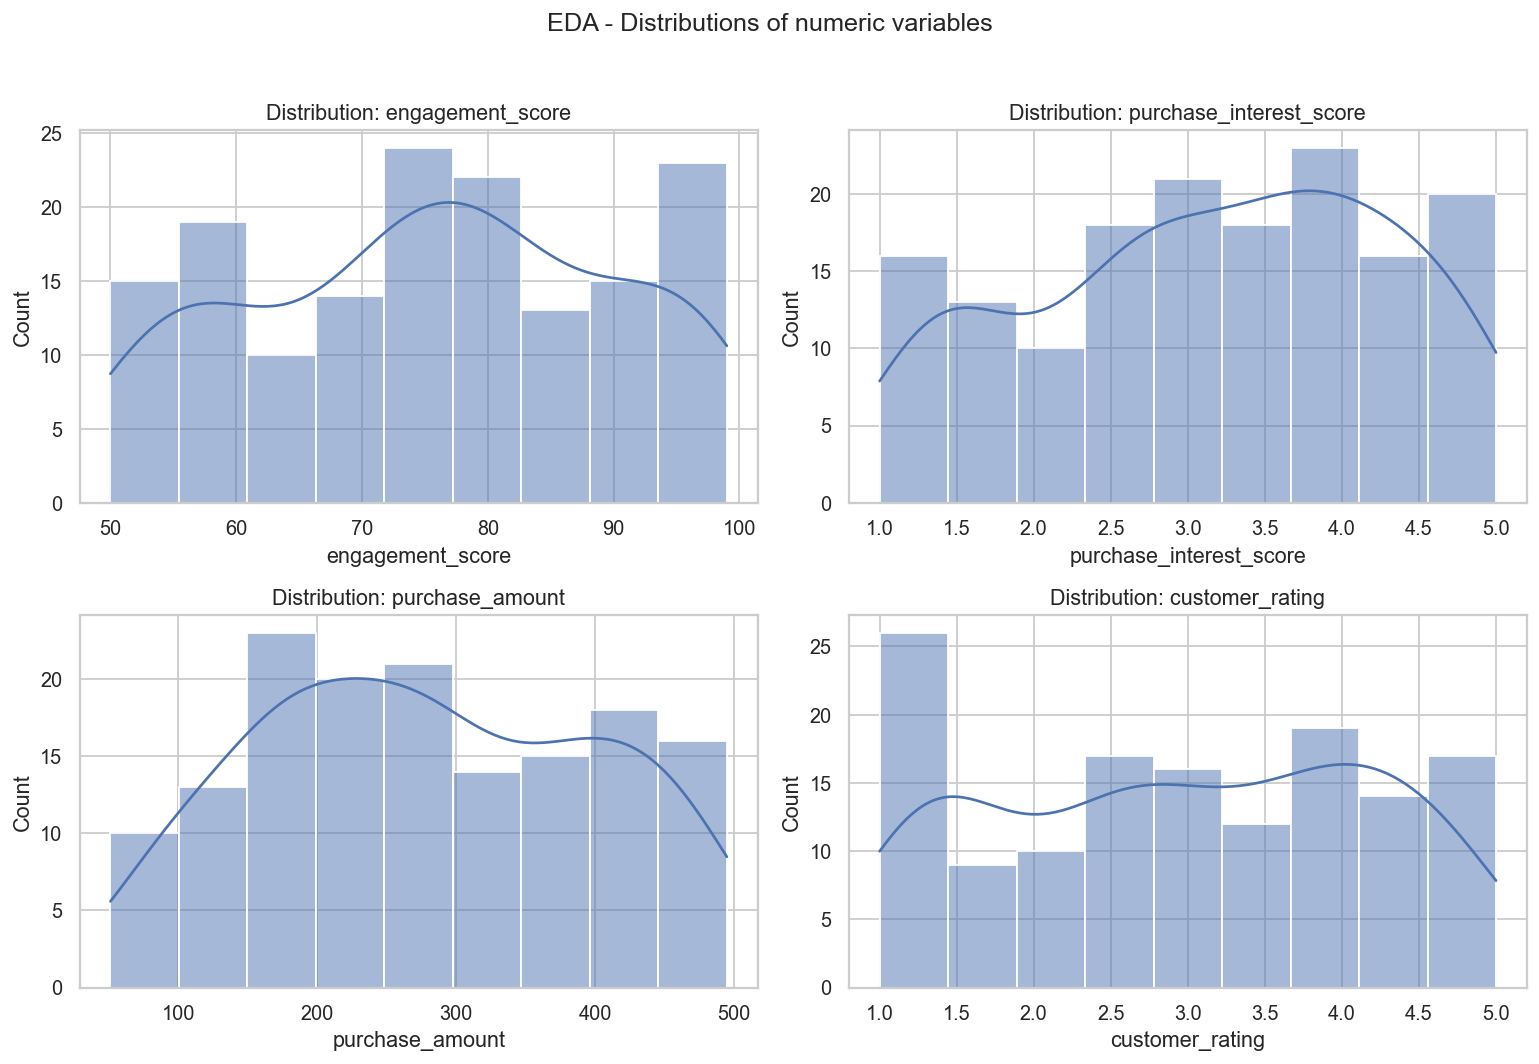

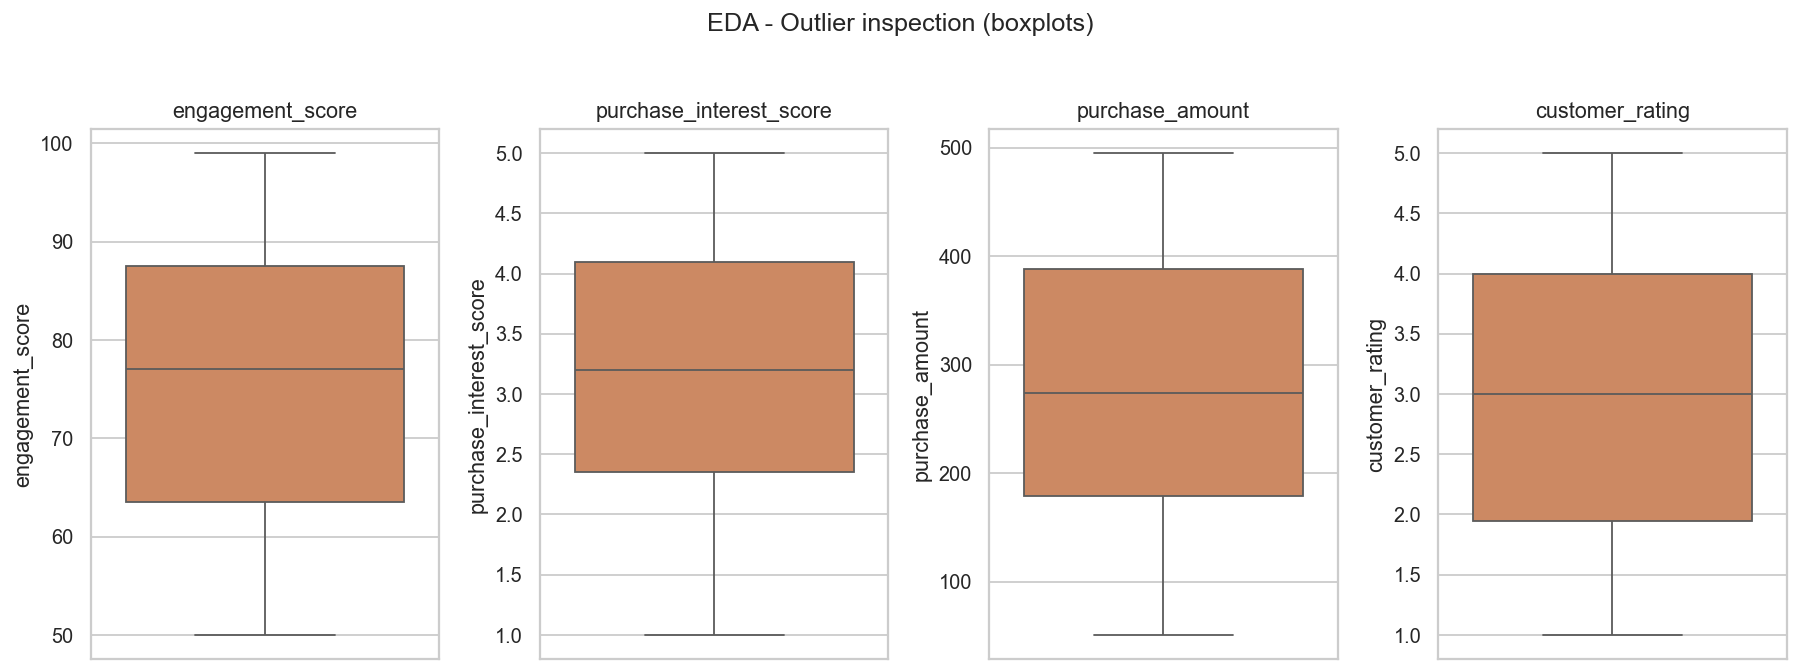

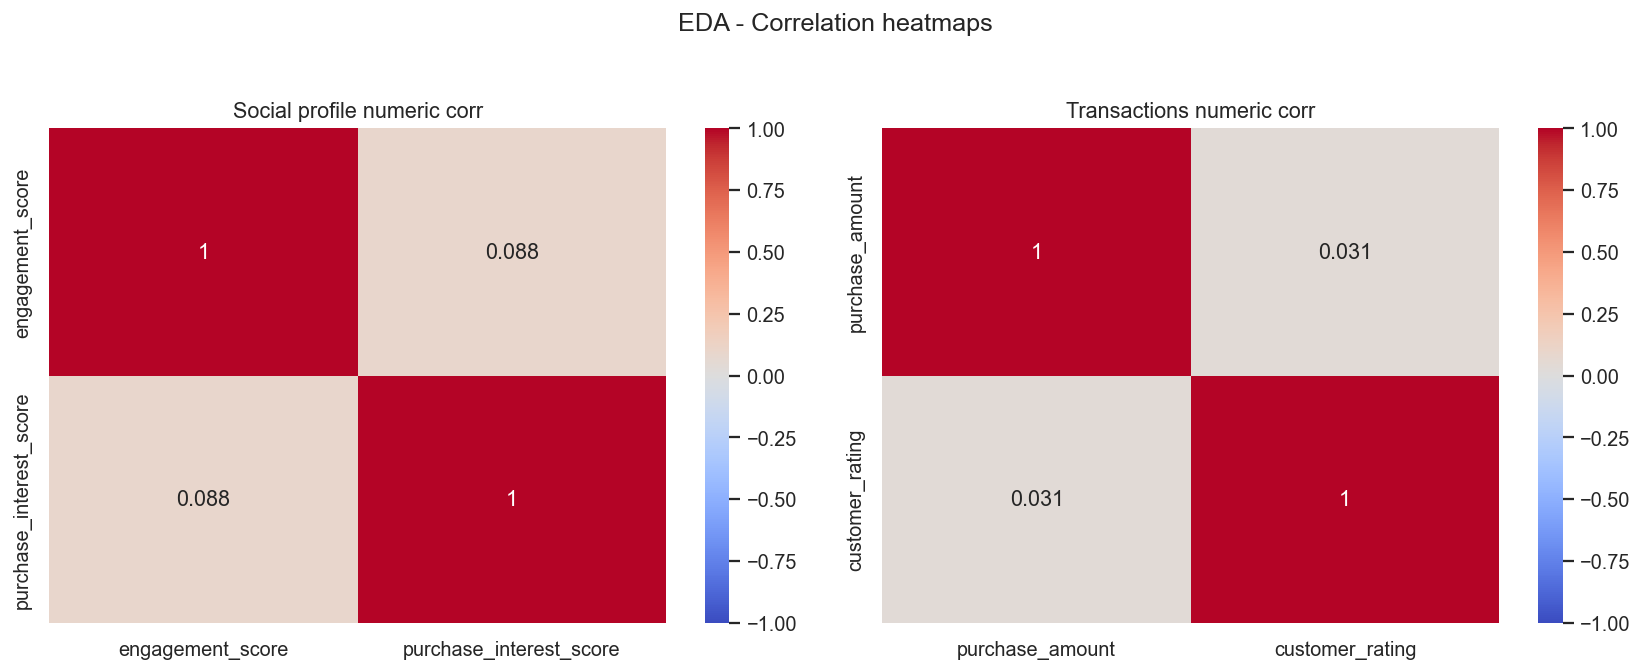

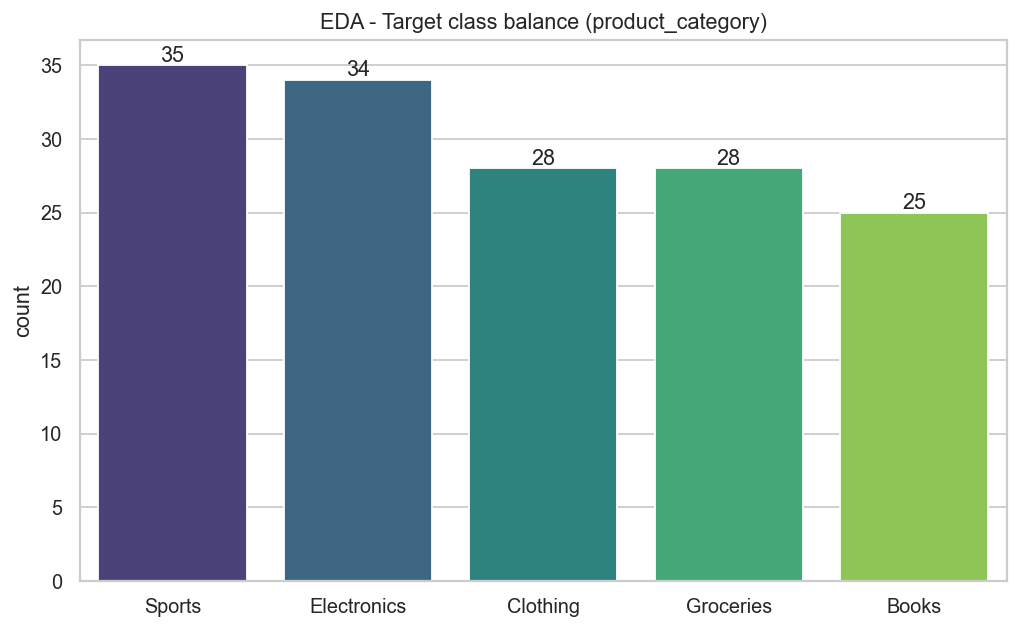

In [4]:
# Displaying Saved plots images for EDA analysis
for pic in ['eda_distributions.png','eda_outliers.png',
          'eda_correlations.png','eda_target_balance.png']:
    display(Image(str(PLOTS / "product_model" / pic)))

### 2. Cleaning & Validated Merge for 2 Datasets
Duplicates dropped, ratings imputed (+ flagged missings), keys reconciled
(`A178`<->`178`), social profile aggregated to one fingerprint per customer, then
left-joined onto transactions. Post-merge checks printed below.

In [7]:
run('2_clean_merge_data.py')

>>> running 2_clean_merge_data.py

[socials] raw shape: (155, 5)
[socials] dropped 5 exact duplicate rows -> (150, 5)
[socials] fingerprint: 84 unique customers, 8 features

[transactions] raw shape: (150, 6)
[transactions] duplicate rows: 0
[transactions] imputed 10 missing ratings with median=3.0

[join] key range trans: 100 - 199
[join] key range social: 100 - 199
[join] customers in BOTH: 61
[join] transactions' customers WITHOUT a social profile: 14

[merge] result shape: (150, 18)
[check] row count preserved (no fan-out): True
[check] transactions with no social match: 33 (22.0%)
[check] remaining nulls after impute: 0
[check] final dtypes ok; target classes: ['Books', 'Clothing', 'Electronics', 'Groceries', 'Sports']

[Done] wrote C:\Users\speci\practice\multimodal-product-recommendation-system\data\cleaned\customer_features.csv  shape=(150, 19)



### 2. Train the product Recommendation model

Running the following cell executes the preprocessing and modeling workflow defined in the project source code.
Baseline -> benchmark (LogReg / RandomForest / XGBoost) -> tune winner model -> evaluate
(Accuracy, Macro-F1, Log-Loss). Includes a mutual-information diagnostic that
explains the score ceiling.

In [8]:
run('3_product_model.py')

>>> running 3_product_model.py
[baseline] majority-class accuracy = 0.237
[cv] LogisticRegression macro-F1 = 0.219
[cv] RandomForest  macro-F1 = 0.220
[cv] XGBoost       macro-F1 = 0.205

[select] winner by CV macro-F1: RandomForest
[tune] best params: {'clf__max_depth': 6, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
[tune] best CV macro-F1: 0.256

[test] accuracy = 0.211  (baseline 0.237)
[test] macro-F1 = 0.193
[test] log-loss = 1.664

[test] classification report:
              precision    recall  f1-score   support

       Books       0.00      0.00      0.00         6
    Clothing       0.25      0.29      0.27         7
 Electronics       0.38      0.33      0.35         9
   Groceries       0.14      0.29      0.19         7
      Sports       0.25      0.11      0.15         9

    accuracy                           0.21        38
   macro avg       0.20      0.20      0.19        38
weighted avg       0.22      0.21      0.20        38



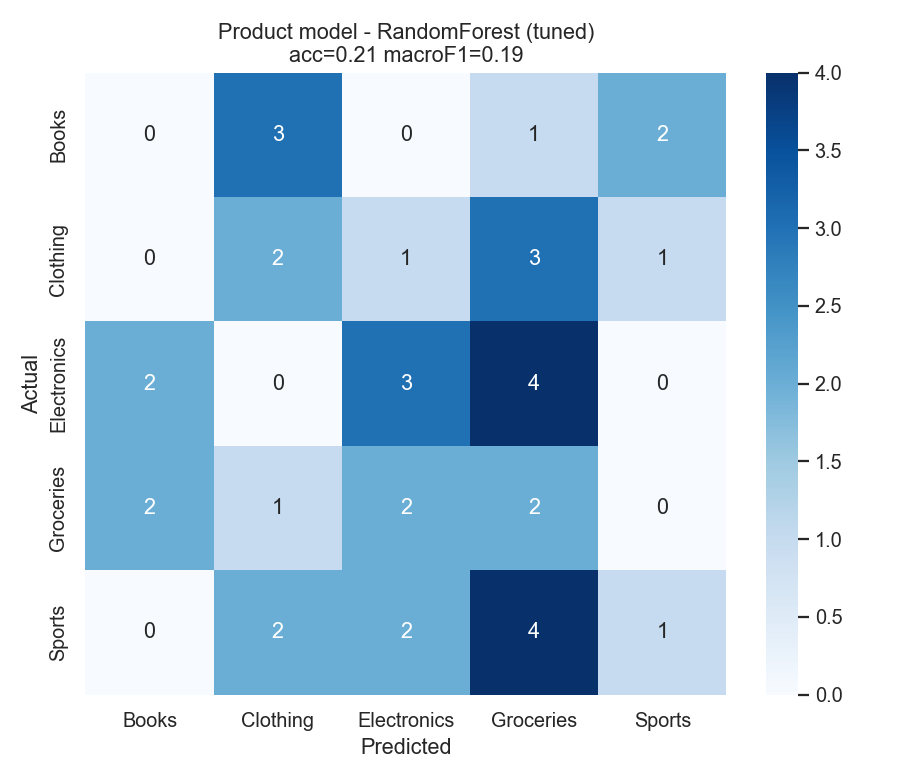

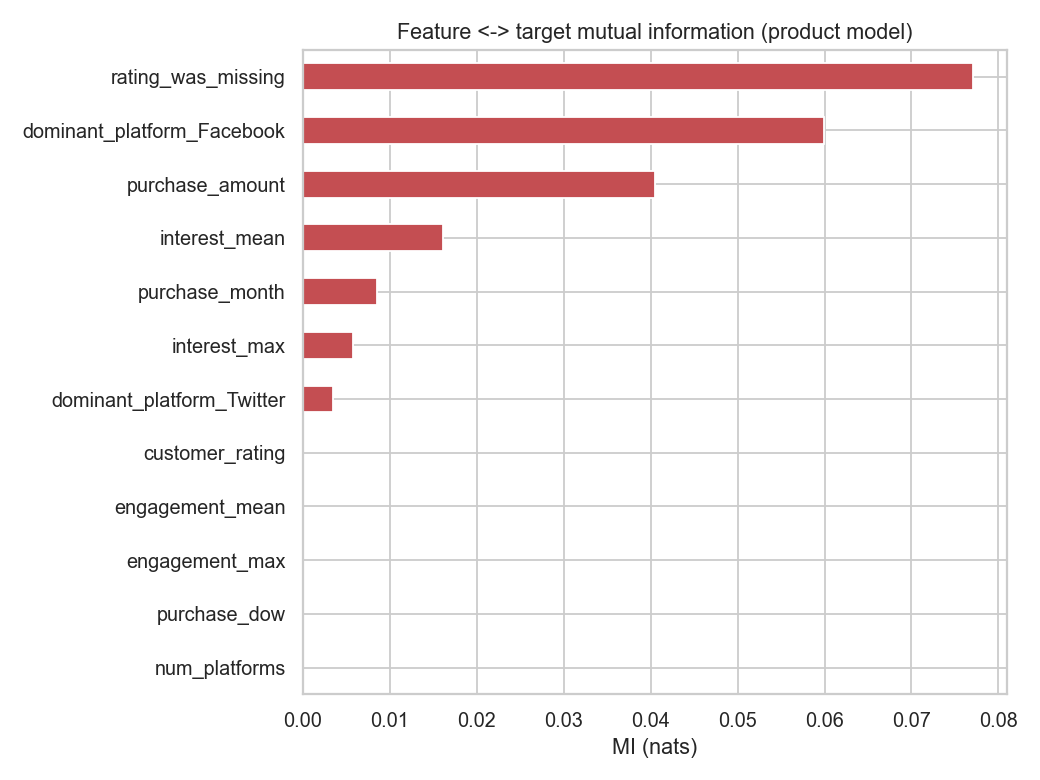

In [9]:
for pic in ['product_confusion_matrix.png','product_mutual_information.png']:
    display(Image(str(PLOTS/ "product_model" /pic)))